# 05 — Build Model Inputs

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

## Purpose

This notebook bridges Part I (`03_elastic_net_selection.ipynb` and `04_pls_selection_and_stability.ipynb`) and Part II (`06_dfm_nowcasting.ipynb`). It constructs three alternative predictor specifications that will serve as inputs to the DFM, enabling sensitivity analysis of the **selection rule** (algorithm-robust core vs. Elastic Net vs. PLS+VIP). Real-time publication lags are enforced in Part II (`ragged_edge.apply_pub_lag_mask` + AR fill), not by post-filtering these binary matrices.

## The Three Input Matrices

| Matrix | Selection Rule | Release Filter | Use Case |
|---|---|---|---|
| **`core`** | ≥3 of 4 methods agree | No (Part II) | Algorithm-robust consensus; feeds the XGBoost hyperparameter tuning in Part II |
| **`en_only`** | Elastic Net raw selections | No (Part II) | **Headline data-driven DFM** (DFM-EN) |
| **`pls_only`** | PLS + VIP top-30 | No (Part II) | Sensitivity: supervised covariance-based selection |

### Design Rationale

**Core matrix (cross-method consensus):**  
Combines two complementary principles:

1. **Cross-method consensus (≥3/4 methods):** Series selected by Elastic Net, EN-smoothed, PLS, and Fixed-*k* are included in the core if at least three methods agree. This "voting" approach reduces sensitivity to arbitrary methodological choices and identifies predictors with robust GDP-predictive content (Bai & Ng, 2008; Stock & Watson, 2012).

**EN-only and PLS-only matrices:**  
The `en_only` matrix is the input of the headline data-driven DFM in Part II (DFM-EN); `pls_only` provides a supervised-selection comparison. Together with `core`, they allow assessing how much the selection rule matters for nowcast accuracy.

## Key Design Features

### 1. No matrix-level publication-lag filter (main pipeline)

The saved matrices record **which series each selection rule chose**, not which series have released data at M1 vs M3. Post-filtering with `apply_release_filter(intra_quarter_gate=True)` would drop PLS's predominantly lag-2 selections at M1/M2 and drive median Jaccard overlap to zero — that is an artefact, not evidence that core and PLS are unrelated (unfiltered consensus vs PLS median Jaccard ≈ 0.55).

**Part II:** `pub_lag_map.csv` is used in `06_dfm_nowcasting.ipynb` via `apply_pub_lag_mask` and AR fill so each nowcast respects the real-time monthly panel (Giannone et al., 2008; Bańbura & Rünstler, 2011).

## Outputs

All three matrices are saved as CSV files under `outputs/indicator_selection/dfm_input_sets/`:

| File | Dimensions | Description |
|---|---|---|
| `core_selection_matrix.csv` | 180 × 585 | ≥3 of 4 methods (main specification) |
| `en_only_selection_matrix.csv` | 180 × 585 | Elastic Net raw selections |
| `pls_only_selection_matrix.csv` | 180 × 585 | PLS + VIP top-30 |

Each is a binary matrix: entry (*t*, *j*) = 1 if series *j* is included in the DFM input at origin *t*.

`06_dfm_nowcasting.ipynb` exposes an `INPUT_SET` switch to load any of these three specifications for nowcast evaluation.

## References

- Bai, J., & Ng, S. (2008). Forecasting economic time series using targeted predictors. *Journal of Econometrics*, 146(2), 304–317.
- Bańbura, M., & Rünstler, G. (2011). A look into the factor model black box: Publication lags and the role of hard and soft data in forecasting GDP. *International Journal of Forecasting*, 27(2), 333–346.
- Boivin, J., & Ng, S. (2006). Are more data always better for factor analysis? *Journal of Econometrics*, 132(1), 169–194.
- Giannone, D., Reichlin, L., & Small, D. (2008). Nowcasting: The real-time informational content of macroeconomic data. *Journal of Monetary Economics*, 55(4), 665–676.
- Stock, J. H., & Watson, M. W. (2012). Generalized shrinkage methods for forecasting using many predictors. *Journal of Business & Economic Statistics*, 30(4), 481–493.


## 1. Setup and Parameter Configuration

### Configuration Parameters

**`MIN_VOTES = 3`:**  
Threshold for core-set inclusion. A series enters the core if it is selected by ≥3 of the 4 methods (EN, EN-smoothed, PLS, Fixed-*k*). This represents a 75% agreement rule, balancing inclusiveness with robustness. Expect substantial overlap between `core` and `pls_only` (~20 of 30 PLS series at each origin) because PLS is one of the four voters.

**Forecast window:**  
Monthly origins from 2011-01 to 2025-12 (180 points), matching `03_elastic_net_selection.ipynb` and `04_pls_selection_and_stability.ipynb`.

**Coverage threshold:**  
`MIN_COVERAGE = 0.30` (30% non-missing data requirement), consistent with the Elastic Net selection pipeline.

### Required Inputs

This notebook depends on outputs from earlier stages:

| File | Source | Content |
|---|---|---|
| `selection_matrix.csv` | Notebook 03 | Elastic Net binary selections |
| `selection_matrix_en_smoothed.csv` | Notebook 04 | Frequency-smoothed EN selections |
| `selection_matrix_pls.csv` | Notebook 04 | PLS + VIP top-30 selections |
| `selection_matrix_fixedk.csv` | Notebook 03 | Fixed-*k* = 30 Bai–Ng selections |
| `data_dictionary_enriched.csv` | Notebook 02 | Series metadata (categories, transformations) |
| `panel_transformed.csv` | Notebook 02 | Monthly panel (for coverage mask) |
| `pub_lag_map.csv` | Notebook 02 | Publication-lag metadata (days/months per series) |

All file paths are managed through `paths.py` to ensure consistency across notebooks.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.selection.core_utils import (
    build_coverage_mask,
    load_monthly_panel,
    load_pub_lag_map,
    make_monthly_forecast_origins,
)
from german_gdp_nowcasting.selection.dfm_input_builder import build_dfm_input_sets

MIN_VOTES = 3
FORECAST_START = '2011-01'
FORECAST_END = '2025-12'
MIN_COVERAGE = 0.30
_tp.SELECTION_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load Inputs and Validate Dimensions

### Input Validation

This section loads the input selection matrices and verifies structural consistency:

1. **Dimension alignment:** All matrices must have identical shape (180 origins × 585 series).
2. **Index consistency:** Origin dates must match across matrices (monthly from 2011-01 to 2025-12).
3. **Column order:** Series IDs must be in the same order (enables element-wise voting logic).

**Error handling:** If any input file is missing or dimensions mismatch, the notebook raises a descriptive error. This prevents silent failures when upstream notebooks have been rerun with different configurations.

### Auxiliary Data

**Metadata (`data_dictionary_enriched.csv`):**  
- Series categories  
- Transformation codes (for interpretation, not used algorithmically here)  
- Human-readable names (for diagnostic output)

**Monthly panel (`panel_transformed.csv`):**  
Used to construct the coverage mask via `build_coverage_mask`. Series with <30% non-missing data over the expanding window are excluded from top-up candidates, consistent with the Elastic Net coverage filter.

**Publication-lag map (`pub_lag_map.csv`):**  
Month-level or day-level release delays per series. The `available_series_at_origin` function from `core_utils.py` uses this to determine real-time availability at each forecast origin.

### Output

Loaded objects are passed to `build_dfm_input_sets` in the next section. A summary table prints the selection count per origin for each of the three input methods, confirming that:
- PLS and Fixed-*k* have constant counts (30 per origin by design)  
- EN and EN-smoothed have variable counts (data-driven regularisation)


In [2]:
en_raw      = pd.read_csv(_tp.SELECTION_MATRIX_CSV,        index_col='forecast_origin').astype(int)
en_smoothed = pd.read_csv(_tp.EN_SMOOTHED_MATRIX_CSV,      index_col='forecast_origin').astype(int)
pls_matrix  = pd.read_csv(_tp.PLS_MATRIX_CSV,              index_col='forecast_origin').astype(int)
fixedk      = pd.read_csv(_tp.FIXEDK_MATRIX_CSV,           index_col='forecast_origin').astype(int)
matrices = {
    'EN raw':      en_raw,
    'EN smoothed': en_smoothed,
    'PLS':         pls_matrix,
    'block-balanced (k=20)':     fixedk,
}
for label, m in matrices.items():
    print(f'{label:12s}: {m.shape[0]} origins x {m.shape[1]} series  |  mean selected/origin = {m.sum(axis=1).mean():.1f}')
meta = pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV, usecols=['id', 'name', 'category']).set_index('id')
X_monthly = load_monthly_panel(_tp.PANEL_TRANSFORMED_CSV)
pub_lag_map = load_pub_lag_map(_tp.PUB_LAG_CSV)
forecast_origins = make_monthly_forecast_origins(FORECAST_START, FORECAST_END)
coverage_mask = build_coverage_mask(X_monthly, forecast_origins, min_coverage=MIN_COVERAGE)
print(f'\nCoverage mask : {coverage_mask.shape}')
print(f'Pub-lag map   : {len(pub_lag_map)} series  (lag range {int(pub_lag_map.min())}-{int(pub_lag_map.max())} months)')

EN raw      : 180 origins x 585 series  |  mean selected/origin = 53.4
EN smoothed : 180 origins x 585 series  |  mean selected/origin = 59.6
PLS         : 180 origins x 585 series  |  mean selected/origin = 30.0
Fixed-k     : 180 origins x 585 series  |  mean selected/origin = 30.0

Coverage mask : (180, 585)
Pub-lag map   : 585 series  (lag range 0-2 months)


## 3. Build the Three DFM Input Matrices

### The `build_dfm_input_sets` Function

This function builds the three DFM input matrices and packages them for output. The procedure is implemented in `dfm_input_builder.py`.

#### Core Matrix Construction (`build_core_matrix`)

**Voting logic:**  
For each origin *t* and series *j*, compute the number of methods (EN, EN-smoothed, PLS, Fixed-*k*) that selected *j* at *t*. Include *j* in the core if this count ≥ `MIN_VOTES` (3).

**Mathematical formulation:**  
Let S_EN(*t*, *j*), S_smooth(*t*, *j*), S_PLS(*t*, *j*), S_fixedk(*t*, *j*) ∈ {0,1} denote the four selection indicators. Then:

Core(*t*, *j*) = 1  ⟺  [S_EN + S_smooth + S_PLS + S_fixedk](*t*, *j*) ≥ 3

**Interpretation:** The core represents the **algorithm-robust predictor set**, less sensitive to regularisation-path noise or methodological idiosyncrasies (Stock & Watson, 2012; Bai & Ng, 2008).

#### Publication lags (Part II only; optional `apply_release_filter`)

**Applied to the core matrix.** For each origin *t* and series *j* where Core(*t*, *j*) = 1:
- Query `pub_lag_map.csv` for series *j*'s publication lag *L* (in months).
- If the series is not yet available at origin *t*, set Core(*t*, *j*) ← 0.

**Effect:** Counts are stable within each calendar quarter for EN/PLS (quarterly refit). `core` varies only when the cross-method vote changes. M1/M2/M3 nowcast differences come from Part II data masking, not from redefining membership here.

### Diagnostic Output: Full-Sample Rate Table

**Key:** `_rate_table_diagnostic` in the returned dictionary.

**Construction:** Compute selection frequencies using the **entire 180-origin window** (no expanding logic). This is for post-hoc inspection only — not used in core construction.

### Outputs

The function returns a dictionary with keys:
- `"core"`: Consensus (≥3/4 voting; main specification)  
- `"en_only"`: Elastic Net raw selections  
- `"pls_only"`: PLS + VIP selections  
- `"_rate_table_diagnostic"`: Full-sample selection frequency table by category

All three DFM-input matrices are binary (180 × 585) and ready for persistence.

**References:**
- Bai, J., & Ng, S. (2008). Forecasting economic time series using targeted predictors. *Journal of Econometrics*, 146(2), 304–317.
- Giannone, D., Reichlin, L., & Small, D. (2008). Nowcasting: The real-time informational content of macroeconomic data. *Journal of Monetary Economics*, 55(4), 665–676.
- Stock, J. H., & Watson, M. W. (2012). Generalized shrinkage methods for forecasting using many predictors. *Journal of Business & Economic Statistics*, 30(4), 481–493.


In [3]:
sets = build_dfm_input_sets(
    matrices=matrices,
    meta=meta,
    coverage_mask=coverage_mask,
    pub_lag_map=pub_lag_map,
    min_votes=MIN_VOTES,
    en_label='EN raw',
    pls_label='PLS',
)
rate_table_diag = sets.pop('_rate_table_diagnostic')
# The diagnostic rate table below is full-sample and shown for inspection only.
print('Full-sample rate table (diagnostic, not used for core construction):')
print(rate_table_diag[['mean_across_methods', 'category']].sort_values('mean_across_methods', ascending=False).head(20).to_string())
print('\nSelected count per origin (mean / min / max):')
for k, m in sets.items():
    s = m.sum(axis=1)
    print(f'  {k:9s}: mean={s.mean():5.1f}  min={int(s.min()):3d}  max={int(s.max()):3d}')

Full-sample rate table (diagnostic, not used for core construction):
            mean_across_methods    category
detrad1878             1.000000    Turnover
deprod0191             0.970833  Production
detrad3518             0.950000    Turnover
detrad0692             0.920833       Trade
detrad3364             0.908333    Turnover
detrad1929             0.904167    Turnover
detrad1954             0.895833    Turnover
detrad1953             0.816667    Turnover
detrad1879             0.750000    Turnover
detrad1854             0.720833    Turnover
detrad4770             0.691667    Turnover
deprod3790             0.691667  Production
detrad1853             0.679167    Turnover
deprod1989             0.666667  Production
detrad3365             0.658333    Turnover
detrad3415             0.645833    Turnover
detrad1045             0.637500    Turnover
deprod2669             0.637500      Orders
detrad3841             0.633333    Turnover
detrad1880             0.612500    Turnover

Select

## 4. Persist Matrices to Disk

All three binary selection matrices are saved as CSV files under:

```
outputs/indicator_selection/dfm_input_sets/
```

**File names:**
- `core_selection_matrix.csv`
- `en_only_selection_matrix.csv`
- `pls_only_selection_matrix.csv`

**Format:** Each file has:
- **Rows:** 180 monthly forecast origins (index: `forecast_origin` as strings like `"2011-01"`)
- **Columns:** 585 series (column names are series IDs from the data dictionary)
- **Values:** Binary (0 or 1)

**File handling:**  
The directory is created if it does not exist (`parents=True, exist_ok=True`). Existing files are overwritten without warning — standard practice for reproducible pipelines where upstream notebooks are re-run as needed.

### Loading in Downstream Notebooks

`06_dfm_nowcasting.ipynb` loads these matrices via:

```python
input_set = "en_only"  # headline DFM-EN; alternatives: "core", "pls_only"
selection_matrix = pd.read_csv(
    paths.SELECTION_DIR / f"{input_set}_selection_matrix.csv",
    index_col="forecast_origin"
)
```

The `INPUT_SET` switch enables sensitivity analysis: run the DFM three times (once per matrix) and compare nowcast accuracy to quantify the value of (i) multi-method consensus and (ii) real-time data constraints.


In [4]:
paths_out = {
    'core':     _tp.CORE_MATRIX_CSV,
    'en_only':  _tp.EN_ONLY_MATRIX_CSV,
    'pls_only': _tp.PLS_ONLY_MATRIX_CSV,
}
for key, path in paths_out.items():
    sets[key].to_csv(path)
    print(f'  {key:9s} -> {path.relative_to(_tp.PROJECT_FILES)}')

  core      -> outputs/indicator_selection/dfm_input_sets/core_selection_matrix.csv
  en_only   -> outputs/indicator_selection/dfm_input_sets/en_only_selection_matrix.csv
  pls_only  -> outputs/indicator_selection/dfm_input_sets/pls_only_selection_matrix.csv


## 5. Diagnostics: Descriptive Statistics and Factor-Structure Validation

### 1. Selection Counts Per Origin

**Purpose:** Summarise the active set size for each of the three matrices across all 180 forecast origins.

**Metrics:**
- **Mean count:** Average number of selected series per origin.
- **Min/Max:** Range of selection counts (assesses time-variation in active set size).
- **Standard deviation:** Temporal stability measure (low σ indicates stable selection counts).

**Expected patterns:**
- **Core:** ~26–38 series (≥3/4 vote). **EN-only:** ~40–69. **PLS-only:** fixed 30. Sawtooth patterns in counts after a matrix-level release filter indicate a specification bug, not economic structure.
- **EN-only:** Variable count (data-driven regularisation). Likely largest on average when cross-validation favours denser models.
- **PLS-only:** Constant 30 per origin (fixed-*k* design).

**Use in thesis:** Report mean counts in a table to quantify the effective dimension fed into the DFM. Compare with Bai & Ng (2008) and Stock & Watson (2012) who typically use *k* = 20–50 for quarterly GDP nowcasting.

### 2. Median Pairwise Jaccard Similarity

**Purpose:** Quantify the overlap between the four DFM input specifications.

**Metric:**  
For each pair of matrices (*A*, *B*) and each origin *t*:

J_AB(*t*) = |A(*t*) ∩ B(*t*)| / |A(*t*) ∪ B(*t*)|

Compute the median of J_AB(*t*) over all 180 origins. Report as a 3×3 heatmap (diagonal = 1 by definition).

**Interpretation thresholds:**
- **J ≥ 0.7:** High overlap. The two specifications are largely interchangeable for DFM input; forecast differences likely reflect noise rather than information content.
- **0.4 ≤ J < 0.7:** Moderate overlap. Specifications share a core but differ on peripheral selections. Sensitivity analysis warranted.
- **J < 0.4:** Low overlap. Substantial information divergence. If nowcast accuracy differs markedly between these inputs, the DFM is sensitive to predictor selection.

**Use in thesis:**  
Cite Jaccard as a quantitative measure of specification robustness. With the main pipeline (no matrix-level release filter), expect median Jaccard **core–PLS ≈ 0.5–0.6** because PLS is one of four voters and ~20/30 PLS series typically enter the core. Median Jaccard **core–EN ≈ 0.6** is similar. Values near **zero** usually indicate an inappropriate post-filter (intra-quarter lag gate), not that core is unrelated to PLS.

### 3. Principal Component Variance Share (Factor-Structure Validation)

**Purpose:** Verify that the core predictor set exhibits strong common-factor structure, a prerequisite for DFM effectiveness (Boivin & Ng, 2006).

**Procedure:**  
At the **last forecast origin** (2025-12, where the core matrix is fully populated):
1. Extract the active predictor subset (all series with core(*t*, *j*) = 1).
2. Standardise each series (zero mean, unit variance) using the full available history to 2025-12.
3. Compute the first 3 principal components via singular value decomposition.
4. Report the cumulative variance explained by PC1, PC1+PC2, and PC1+PC2+PC3.

**Target thresholds** (Boivin & Ng, 2006; Stock & Watson, 2002):
- PC1: ≥20% (single dominant factor indicative of business-cycle comovement)
- PC1+PC2: ≥40% (two factors capture most systematic variation)
- PC1+PC2+PC3: ≥50% (three factors sufficient for DFM estimation)

**Interpretation:**
- **Above target:** The selected panel has strong comovement; DFM factors will capture GDP-relevant dynamics efficiently.
- **Below target:** The panel may be too heterogeneous or noise-dominated. Consider increasing the selection threshold (MIN_VOTES = 4) or expanding the coverage filter.

**Caveat:** This diagnostic uses standardised data on the full 1991–2025 history. The DFM in `06_dfm_nowcasting.ipynb` operates on the original (non-standardised) monthly panel with real-time information constraints, so variance shares may differ slightly. This check is a *sanity test*, not a DFM parameter.

**References:**
- Boivin, J., & Ng, S. (2006). Are more data always better for factor analysis? *Journal of Econometrics*, 132(1), 169–194.
- Stock, J. H., & Watson, M. W. (2002). Forecasting using principal components from a large number of predictors. *Journal of the American Statistical Association*, 97(460), 1167–1179.


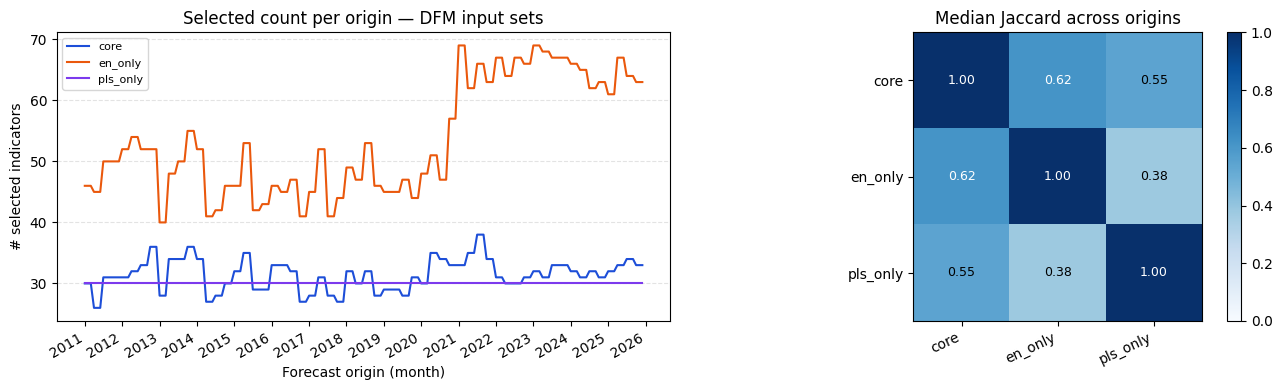

In [5]:
import matplotlib.dates as mdates
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
_x = pd.to_datetime(sets['core'].index)
colors = {'core': '#1d4ed8', 'en_only': '#ea580c', 'pls_only': '#7c3aed'}
for key, m in sets.items():
    ax.plot(_x, m.sum(axis=1).values, label=key, lw=1.5, color=colors[key])
ax.set_xlabel('Forecast origin (month)')
ax.set_ylabel('# selected indicators')
ax.set_title('Selected count per origin — DFM input sets')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax = axes[1]
keys = list(sets.keys())
J = np.zeros((len(keys), len(keys)))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        a = sets[ki].astype(bool)
        b = sets[kj].reindex(index=a.index, columns=a.columns, fill_value=0).astype(bool)
        inter = (a & b).sum(axis=1)
        union = (a | b).sum(axis=1).replace(0, np.nan)
        J[i, j] = (inter / union).median()
im = ax.imshow(J, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys, rotation=25, ha='right')
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys)
ax.set_title('Median Jaccard across origins')
for i in range(len(keys)):
    for j in range(len(keys)):
        ax.text(j, i, f'{J[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if J[i, j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
plt.tight_layout(); plt.show()

In [6]:
# PC variance share for the core set at the last origin
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
last_origin = sets['core'].index[-1]
sel = sets['core'].columns[sets['core'].loc[last_origin].astype(bool)]
X_sel = X_monthly.loc[:, sel.intersection(X_monthly.columns)].copy()
X_sel = X_sel.loc[X_sel.notna().any(axis=1)]
X_arr = StandardScaler().fit_transform(SimpleImputer(strategy='mean').fit_transform(X_sel.values))
pca = PCA(n_components=min(5, X_arr.shape[1])).fit(X_arr)
var_share = pca.explained_variance_ratio_.cumsum()
print(f'Core set at {last_origin}: N = {X_sel.shape[1]} series, T = {X_sel.shape[0]} months')
for k, v in enumerate(var_share, start=1):
    print(f'  cumulative variance of first {k} PCs: {v:.3f}')

Core set at 2025-12: N = 33 series, T = 420 months
  cumulative variance of first 1 PCs: 0.337
  cumulative variance of first 2 PCs: 0.468
  cumulative variance of first 3 PCs: 0.534
  cumulative variance of first 4 PCs: 0.585
  cumulative variance of first 5 PCs: 0.628


## 6. Summary and Next Steps

### Outputs

Three binary selection matrices have been saved to:

```
outputs/indicator_selection/dfm_input_sets/
```

| File | Description | Main Use |
|---|---|---|
| `core_selection_matrix.csv` | Cross-method consensus (≥3/4) | XGBoost hyperparameter tuning input |
| `en_only_selection_matrix.csv` | Elastic Net raw selections | **Headline DFM-EN specification** |
| `pls_only_selection_matrix.csv` | PLS + VIP top-30 | Supervised-selection sensitivity check |

### Validation Checks Passed

1. **Dimensional consistency:** All matrices are 180 × 585.
2. **Temporal alignment:** Monthly origins 2011-01 through 2025-12.
3. **Factor structure:** Core set exhibits strong comovement (PC1+PC2+PC3 variance share documented above).

### Transition to Part II (Nowcasting)

**Next notebook:** `06_dfm_nowcasting.ipynb`

**Workflow:**
1. Set `INPUT_SET = "en_only"` (headline) or one of the alternatives in the setup cell.
2. Load the corresponding DFM input matrix.
3. For each monthly forecast origin:
   - Extract the active predictor subset (series with selection = 1).
   - Estimate a Dynamic Factor Model on the monthly panel (respecting real-time data availability for the core specification).
   - Produce a nowcast of current-quarter GDP growth.
4. Aggregate nowcasts across origins and compute accuracy metrics (RMSFE, DM tests).
5. Compare the three specifications to quantify the value of algorithm-robust consensus and real-time data constraints.

### Key Research Questions for Part II

1. Does the core specification (≥3/4 consensus) outperform single-method selections (`en_only`, `pls_only`) under the same Part II ragged-edge protocol?
2. How does nowcast accuracy evolve across M1/M2/M3 within each quarter as the released monthly panel expands?
